open proyecto → bring changes from  GitHub → work → save → git add → git commit → git push

BONDS
# Bonds & Yields Project

## Risk Management - Valuation and Hedging

This project studies the valuation and hedging of bonds using spot rates, forward rates, YTM, duration, DV01 and convexity. The analysis is based on ECB spot yields

Question1
Define a bond and explain how it is issued. Explain the relationship between bonds and interest rates.

A bond is a fixed-income security that represents a loan made by an investor to an issuer. Bonds are typically issued by governments, financial institutions, or corporations, and they generally provide periodic coupon payments together with the repayment of principal at maturity. From the investor’s perspective, bonds are often used to generate relatively stable income and to diversify a portfolio.

A key characteristic of bonds is the inverse relationship between bond prices and market interest rates. When market interest rates increase, the price of existing fixed-rate bonds decreases. This is because the value of a bond depends on the present value of its future cash flows. If newly issued bonds offer higher yields, previously issued bonds with lower coupon rates become less attractive, so their prices must fall to remain competitive in the market.

Question 2 data selection



In [1]:
import pandas as pd

#  Read raw data
raw_path = "../data/raw/ecb_spot_rates_raw.csv"
df_raw = pd.read_csv(raw_path)

print(df_raw.columns.tolist())
print(df_raw.head())

['DATE', 'TIME PERIOD', 'AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y)', 'AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M)', 'AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y)', 'AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M)', 'AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y)', 'AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M)', 'AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y)', 'AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M)', 'AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y)', 'AAA yield curve - 5-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y6M)', 'AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M)', 'AAA yield curve - 6-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y)', 'AAA yield curve - 6-year

In [2]:
# Convert date column
df_raw["DATE"] = pd.to_datetime(df_raw["DATE"])

# Choose latest available date
selected_date = df_raw["DATE"].max()


print("Selected date:", selected_date.date())

# Filter the selected row
df_selected = df_raw[df_raw["DATE"] == selected_date].copy()

print("Rows found for selected date:", len(df_selected))
df_selected.head()

Selected date: 2026-03-19
Rows found for selected date: 1


,DATE,TIME PERIOD,AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y),AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M),AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y),AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M),AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y),AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M),AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y),AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M),AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y),AAA yield curve - 5-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y6M),AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M),AAA yield curve - 6-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y),AAA yield curve - 6-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6Y6M)
5504,2026-03-19,19 Mar 2026,2.337735,2.424372,2.468185,2.49495,2.517302,2.540909,2.567863,2.598506,2.632398,2.668812,2.158183,2.706979,2.746191


In [9]:
# 6M to 5Y = 10 periods
SEMIANNUAL_COLS = {
    "SR_6M":   (0.5,  "0.5Y"),
    "SR_1Y":   (1.0,  "1.0Y"),
    "SR_1Y6M": (1.5,  "1.5Y"),
    "SR_2Y":   (2.0,  "2.0Y"),
    "SR_2Y6M": (2.5,  "2.5Y"),
    "SR_3Y":   (3.0,  "3.0Y"),
    "SR_3Y6M": (3.5,  "3.5Y"),
    "SR_4Y":   (4.0,  "4.0Y"),
    "SR_4Y6M": (4.5,  "4.5Y"),
    "SR_5Y":   (5.0,  "5.0Y"),
}

# Match raw columns by their key 
def find_col(df, key):
    matches = [c for c in df.columns if key in c]
    return matches[0]

# Build  DataFrame
records = []
for key, (maturity, label) in SEMIANNUAL_COLS.items():
    col = find_col(df_selected, key)
    records.append({
        "maturity_years": maturity,
        "maturity_label": label,
        "spot_rate":      df_selected[col].iloc[0] / 100,  # decimal form
    })

df_curve = pd.DataFrame(records)
df_curve["date"] = selected_date.date()
df_curve = df_curve[["date", "maturity_label", "maturity_years", "spot_rate"]]

print(df_curve.to_string(index=False))

      date maturity_label  maturity_years  spot_rate
2026-03-19           0.5Y             0.5   0.021582
2026-03-19           1.0Y             1.0   0.023377
2026-03-19           1.5Y             1.5   0.024244
2026-03-19           2.0Y             2.0   0.024682
2026-03-19           2.5Y             2.5   0.024949
2026-03-19           3.0Y             3.0   0.025173
2026-03-19           3.5Y             3.5   0.025409
2026-03-19           4.0Y             4.0   0.025679
2026-03-19           4.5Y             4.5   0.025985
2026-03-19           5.0Y             5.0   0.026324


Question 3:Define a spot rate and its characteristics Explain the method through which spot rates are derived from the market. Plot the
spot yield curve. Interpret from a macroeconomic perspective

Spot rates are the market discount rates applied to zero-coupon bonds for specific maturities. They are also called spot yields and are used to discount a single future cash flow to its present value. In this sense, they reflect the time value of money for a given period without intermediate cash flows. Spot rates differ across maturities, which is why they form a spot yield curve.

Spot rates are derived from market bond prices under a no-arbitrage framework. For zero-coupon bonds, the spot rate can be obtained directly, since the bond pays only one cash flow at maturity. For coupon-bearing bonds, spot rates are estimated through a bootstrapping method. The process starts with the shortest maturities, whose spot rates are identified first, and then progressively moves to longer maturities. At each step, previously derived spot rates are used to discount earlier cash flows, and the remaining unknown rate is solved using the observed bond price. Repeating this procedure across maturities makes it possible to construct the entire spot yield curve.
In this project, we use the ECB’s already estimated AAA spot yield curve, which is constructed from market bond data using the ECB yield curve methodology.

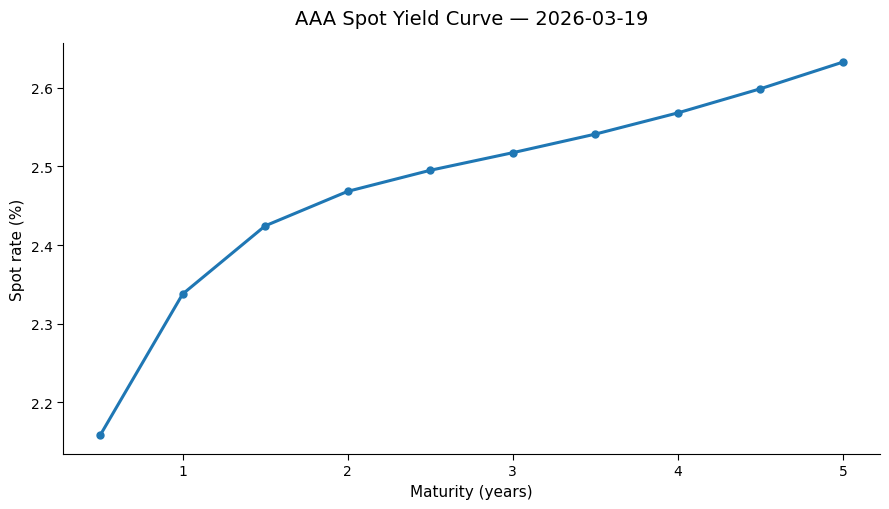

In [ ]:
import matplotlib.pyplot as plt


# Convert to percentage only for display
x = df_curve["maturity_years"]
y = df_curve["spot_rate"] * 100

plt.figure(figsize=(9, 5.2))
plt.plot(
    x, y,
    linewidth=2.2,
    marker="o",
    markersize=5
)

plt.title(f"AAA Spot Yield Curve — {selected_date.date()}", fontsize=14, pad=14)
plt.xlabel("Maturity (years)", fontsize=11)
plt.ylabel("Spot rate (%)", fontsize=11)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)
ax.grid(False)

plt.tight_layout()
plt.show()

The shape of the yield curve reflects the relationship between short-, medium-, and long-term interest rates. It can provide useful information about market expectations and the general economic outlook. In this case, the AAA spot yield curve is upward sloping over the 0.5 to 5-year horizon. From a macroeconomic perspective, this suggests that markets expect future short-term interest rates to remain relatively high or to increase moderately compared with current short-term rates. This is consistent with a normal yield curve and may reflect expectations of resilient economic activity, stable inflation dynamics, and a positive term premium on longer maturities.

The curve is steeper at the short end and then becomes more gradual after around two years. This may indicate that the main monetary policy adjustment is expected to occur in the near to medium term, while longer-term expectations remain more anchored. In other words, short-term monetary policy expectations appear to be more sensitive to current macroeconomic conditions, whereas longer-term inflation and growth expectations seem more stable.

Question4/ Using two non-consecutive semi-annual spot yields (for example, n1 and n3, where “n” defines the 10 semi-annual spot yields
you have selected), perform a linear interpolation to estimate the value of another semi-annual spot yield (for example, n2).
Compare the estimated value of the semi-annual spot yield to the observed one. Interpret.

The linear interpolation formula is:


- $T_L$ be the lower maturity,
- $T_U$ be the upper maturity,
- $T^*$ be the intermediate maturity to be estimated,
- $s(T_L)$ be the observed spot yield at the lower maturity,
- $s(T_U)$ be the observed spot yield at the upper maturity.

The interpolated spot yield is given by:

$$
\tilde{s}(T^*) = s(T_L) + \frac{T^* - T_L}{T_U - T_L}\left[s(T_U) - s(T_L)\right]
$$

In [13]:
# Lower, target, and upper maturities
T_L = 1.0
T_star = 1.5
T_U = 2.0

# Observed spot yields
s_L = df_curve.loc[df_curve["maturity_years"] == T_L, "spot_rate"].iloc[0]
s_star_obs = df_curve.loc[df_curve["maturity_years"] == T_star, "spot_rate"].iloc[0]
s_U = df_curve.loc[df_curve["maturity_years"] == T_U, "spot_rate"].iloc[0]

print("Lower maturity:", T_L, "Observed spot rate:", s_L)
print("Target maturity:", T_star, "Observed spot rate:", s_star_obs)
print("Upper maturity:", T_U, "Observed spot rate:", s_U)

Lower maturity: 1.0 Observed spot rate: 0.023377349999999998
Target maturity: 1.5 Observed spot rate: 0.02424372
Upper maturity: 2.0 Observed spot rate: 0.02468185


In [14]:
# Linear interpolation
s_star_interp = s_L + ((T_star - T_L) / (T_U - T_L)) * (s_U - s_L)

print("Interpolated spot rate at", T_star, "years:", s_star_interp)

Interpolated spot rate at 1.5 years: 0.024029599999999998


In [23]:
# Difference between observed and interpolated values
difference = s_star_obs - s_star_interp
difference_bps = difference * 10000  # convert to basis points

print("Observed spot rate:     ", round(s_star_obs, 6))
print("Interpolated spot rate: ", round(s_star_interp, 6))
print("Difference:             ", round(difference,6))
print("Difference (bps):       ", round(difference_bps,2))

Observed spot rate:      0.024244
Interpolated spot rate:  0.02403
Difference:              0.000214
Difference (bps):        2.14


The interpolated 1.5-year spot yield is slightly below the observed one. The gap is equal to 0.000214(2.14 basis points). This indicates that the actual curve is not exactly linear between the 1-year and 2-year maturities, but the difference is small enough to conclude that linear interpolation remains a good approximation over this interval.

Question 5

Question 6

Question 7

Question 8

Question 9

Question 10

Question 11